# Slide-deck figures

Produces the seven figures used in the report. Run all cells; figures are written to this folder as PNG/PDF.

**Note**: Plot 7 (tile-visit heatmaps) loads each `agent.pt` and rolls out 30 evaluation episodes per condition per budget; expect a few minutes on CPU.

## Setup

In [1]:
import csv, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PROJECT = Path.cwd().parent
OUT_DIR = PROJECT / 'slide_deck_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONDITION_ORDER = ['surprisal', 'expected_info_gain', 'info_gain', 'novelty', 'random', 'hybrid']
CONDITION_LABELS_LINE = {
    'surprisal': 'Predictive surprisal',
    'expected_info_gain': 'Expected IG (BALD)',
    'info_gain': 'Dirichlet IG',
    'novelty': 'Novelty',
    'random': 'Random',
    'hybrid': 'Hybrid',
}
CONDITION_LABELS_BAR = {
    'surprisal': 'Predictive\nsurprisal',
    'expected_info_gain': 'Expected IG\n(BALD)',
    'info_gain': 'Dirichlet IG',
    'novelty': 'Novelty',
    'random': 'Random',
    'hybrid': 'Hybrid',
}
CONDITION_COLORS = {
    'info_gain': '#534AB7',
    'expected_info_gain': '#2C7BB6',
    'surprisal': '#C77C17',
    'novelty': '#1D9E75',
    'random': '#888780',
    'hybrid': '#D4537E',
}
print('Output folder:', OUT_DIR)

Output folder: /Users/mingzeli/Documents/GitHub/info_theory_exploration/chromatic_white_submission/slide_deck_figures


### Helpers

In [2]:
def load_summary(budget):
    path = PROJECT / f'figures_white_{budget}/summary.csv'
    return list(csv.DictReader(open(path)))

def mean_sem(rows, key):
    vals = []
    for r in rows:
        v = r.get(key, '')
        if v in ('', None):
            continue
        try:
            vv = float(v)
            if not np.isnan(vv):
                vals.append(vv)
        except (TypeError, ValueError):
            continue
    if not vals:
        return np.nan, 0.0, np.array([])
    arr = np.array(vals, dtype=float)
    sem = arr.std(ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
    return float(arr.mean()), float(sem), arr

def load_runs(runs_dir):
    runs_by_cond = {c: [] for c in CONDITION_ORDER}
    for d in sorted(Path(runs_dir).iterdir()):
        if not d.is_dir() or '_seed' not in d.name:
            continue
        cond, seed_str = d.name.rsplit('_seed', 1)
        if cond not in runs_by_cond:
            continue
        try:
            hist = json.load(open(d / 'history.json'))
        except FileNotFoundError:
            continue
        runs_by_cond[cond].append({'seed': int(seed_str), 'history': hist, 'run_dir': d})
    return runs_by_cond

def aligned_curve(runs, key, y_floor=None, n_pts=120):
    valid = []
    for r in runs:
        xs = np.array([h['global_step'] for h in r['history']], dtype=float)
        ys = np.array([h.get(key, np.nan) for h in r['history']], dtype=float)
        if y_floor is not None:
            ys = np.maximum(ys, y_floor)
        mask = ~np.isnan(ys)
        if mask.sum() > 1:
            valid.append((xs[mask], ys[mask]))
    if not valid:
        return None
    x_min = max(xs.min() for xs, _ in valid)
    x_max = min(xs.max() for xs, _ in valid)
    if x_max <= x_min:
        return None
    grid = np.linspace(x_min, x_max, n_pts)
    aligned = np.vstack([np.interp(grid, xs, ys) for xs, ys in valid])
    mean = aligned.mean(axis=0)
    sem = (aligned.std(axis=0, ddof=1) / np.sqrt(aligned.shape[0])
           if aligned.shape[0] > 1 else np.zeros_like(mean))
    return grid, mean, sem

def load_episode_histories(runs_dir):
    out = {c: [] for c in CONDITION_ORDER}
    for d in sorted(Path(runs_dir).iterdir()):
        if not d.is_dir() or '_seed' not in d.name:
            continue
        cond, _ = d.name.rsplit('_seed', 1)
        if cond not in out:
            continue
        ep_path = d / 'episode_history.json'
        if ep_path.exists():
            out[cond].append(json.load(open(ep_path)))
    return out

def smooth(x, k):
    if k <= 1 or len(x) < 3:
        return x
    return np.convolve(x, np.ones(k) / k, mode='same')

runs_600 = load_runs(PROJECT / 'runs_white_600')
ep_600 = load_episode_histories(PROJECT / 'runs_white_600')
for c in CONDITION_ORDER:
    print(f'{c:25s}  {len(runs_600[c])} run(s)  /  {len(ep_600[c])} eps loaded')

surprisal                  3 run(s)  /  3 eps loaded
expected_info_gain         3 run(s)  /  3 eps loaded
info_gain                  3 run(s)  /  3 eps loaded
novelty                    3 run(s)  /  3 eps loaded
random                     3 run(s)  /  3 eps loaded
hybrid                     3 run(s)  /  3 eps loaded


## Plot 1: eval success rate at three episode budgets

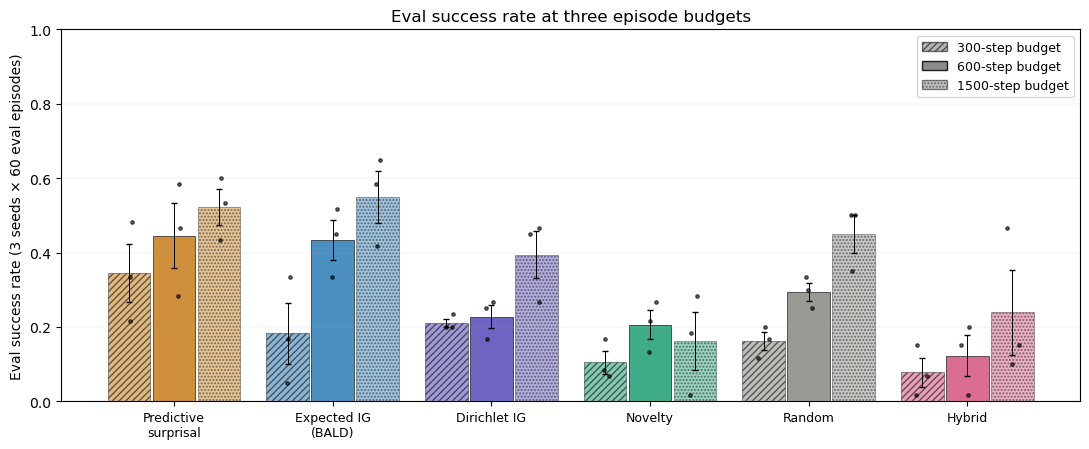

In [3]:
BUDGETS = [300, 600, 1500]
BUDGET_HATCH = {300: '/////', 600: '', 1500: '.....'}
BUDGET_ALPHA = {300: 0.55, 600: 0.85, 1500: 0.45}

data = {b: load_summary(b) for b in BUDGETS}

fig, ax = plt.subplots(figsize=(11, 4.6))
n_bud = len(BUDGETS)
bar_w = 0.85 / n_bud
np.random.seed(0)
for j, b in enumerate(BUDGETS):
    rows_by_cond = {c: [r for r in data[b] if r['condition'] == c] for c in CONDITION_ORDER}
    for i, cond in enumerate(CONDITION_ORDER):
        m, s, vals = mean_sem(rows_by_cond[cond], 'eval_success_rate')
        x = i + (j - (n_bud - 1) / 2) * bar_w
        ax.bar(x, m, width=bar_w * 0.95, yerr=s,
               color=CONDITION_COLORS[cond], alpha=BUDGET_ALPHA[b],
               hatch=BUDGET_HATCH[b], edgecolor='black', linewidth=0.5,
               error_kw={'linewidth': 0.7, 'capsize': 2.5})
        if len(vals):
            jitter = np.random.uniform(-bar_w * 0.15, bar_w * 0.15, size=len(vals))
            ax.scatter(np.full(len(vals), x) + jitter, vals,
                       color='black', s=6, alpha=0.6, zorder=3)

handles = [Patch(facecolor='#777', alpha=BUDGET_ALPHA[b],
                 hatch=BUDGET_HATCH[b], edgecolor='black',
                 label=f'{b}-step budget') for b in BUDGETS]
ax.legend(handles=handles, loc='upper right', fontsize=9, frameon=True)
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels([CONDITION_LABELS_BAR[c] for c in CONDITION_ORDER], fontsize=9)
ax.set_ylabel('Eval success rate (3 seeds × 60 eval episodes)')
ax.set_title('Eval success rate at three episode budgets', fontsize=12)
ax.grid(True, axis='y', linewidth=0.3, alpha=0.4)
ax.set_ylim(0, 1.0)
fig.tight_layout()
fig.savefig(OUT_DIR / '1_eval_success_rate_3budget_bar.png', dpi=220)
fig.savefig(OUT_DIR / '1_eval_success_rate_3budget_bar.pdf')
plt.show()

## Plot 2: intrinsic-reward magnitude over training (600-step budget)

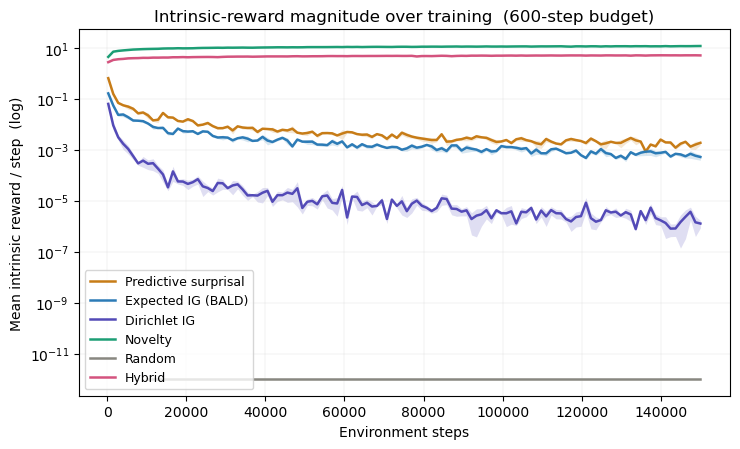

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for cond in CONDITION_ORDER:
    res = aligned_curve(runs_600[cond], 'mean_int_reward_per_step', y_floor=1e-12)
    if res is None:
        continue
    x, mean, sem = res
    color = CONDITION_COLORS[cond]
    ax.plot(x, mean, color=color, label=CONDITION_LABELS_LINE[cond], linewidth=1.8)
    ax.fill_between(x, np.maximum(mean - sem, 1e-12), mean + sem,
                    color=color, alpha=0.18, linewidth=0)
ax.set_yscale('log')
ax.set_xlabel('Environment steps')
ax.set_ylabel('Mean intrinsic reward / step  (log)')
ax.set_title('Intrinsic-reward magnitude over training  (600-step budget)', fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', linewidth=0.3, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / '2_intrinsic_reward_log.png', dpi=220)
fig.savefig(OUT_DIR / '2_intrinsic_reward_log.pdf')
plt.show()

## Plot 3: training episode length over time (600-step budget)

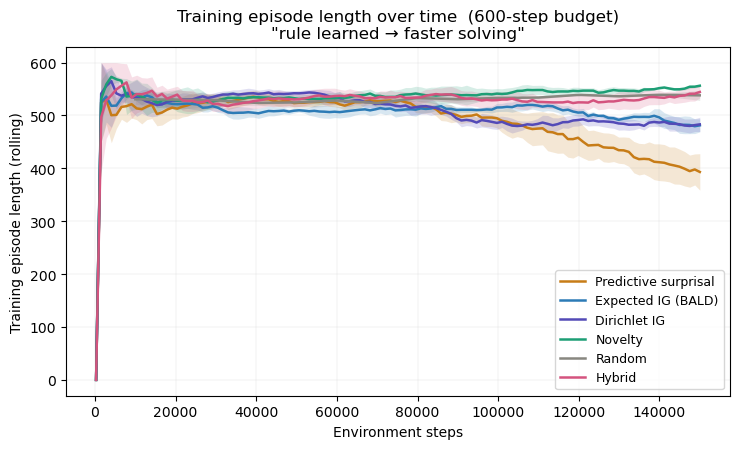

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for cond in CONDITION_ORDER:
    res = aligned_curve(runs_600[cond], 'mean_ep_len')
    if res is None:
        continue
    x, mean, sem = res
    color = CONDITION_COLORS[cond]
    ax.plot(x, mean, color=color, label=CONDITION_LABELS_LINE[cond], linewidth=1.8)
    ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.18, linewidth=0)
ax.set_xlabel('Environment steps')
ax.set_ylabel('Training episode length (rolling)')
ax.set_title('Training episode length over time  (600-step budget)\n"rule learned → faster solving"',
             fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, linewidth=0.3, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / '3_training_episode_length.png', dpi=220)
fig.savefig(OUT_DIR / '3_training_episode_length.pdf')
plt.show()

## Plot 4: steps to solve indexed by solve number (600-step budget)

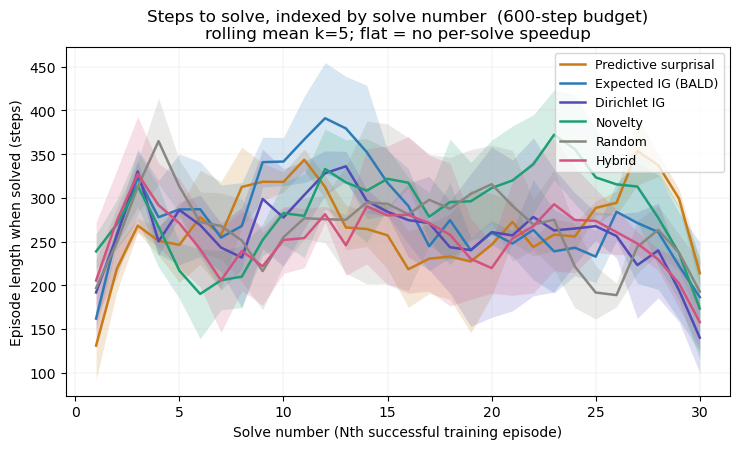

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for cond in CONDITION_ORDER:
    seeds_eps = ep_600[cond]
    if not seeds_eps:
        continue
    seqs = [[e['length'] for e in eps if e.get('solved')] for eps in seeds_eps]
    n = min(min(len(s) for s in seqs) if seqs else 0, 30)
    if n < 5:
        continue
    arr = np.array([s[:n] for s in seqs], dtype=float)
    arr = np.array([smooth(row, 5) for row in arr])
    x = np.arange(1, n + 1)
    mean = arr.mean(axis=0)
    sem = (arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
           if arr.shape[0] > 1 else np.zeros_like(mean))
    color = CONDITION_COLORS[cond]
    ax.plot(x, mean, color=color, label=CONDITION_LABELS_LINE[cond], linewidth=1.8)
    ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.18, linewidth=0)
ax.set_xlabel('Solve number (Nth successful training episode)')
ax.set_ylabel('Episode length when solved (steps)')
ax.set_title('Steps to solve, indexed by solve number  (600-step budget)\n'
             'rolling mean k=5; flat = no per-solve speedup',
             fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linewidth=0.3, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / '4_solve_time_vs_solve_number.png', dpi=220)
fig.savefig(OUT_DIR / '4_solve_time_vs_solve_number.pdf')
plt.show()

## Plot 5: rule learning (KL true rule || learned posterior) over training (600-step budget)

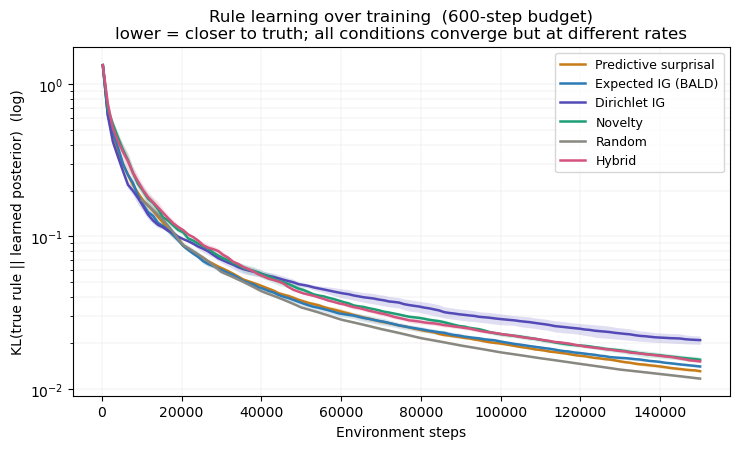

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for cond in CONDITION_ORDER:
    res = aligned_curve(runs_600[cond], 'wm_kl_to_truth', y_floor=1e-12)
    if res is None:
        continue
    x, mean, sem = res
    color = CONDITION_COLORS[cond]
    ax.plot(x, mean, color=color, label=CONDITION_LABELS_LINE[cond], linewidth=1.8)
    ax.fill_between(x, np.maximum(mean - sem, 1e-12), mean + sem,
                    color=color, alpha=0.18, linewidth=0)
ax.set_yscale('log')
ax.set_xlabel('Environment steps')
ax.set_ylabel('KL(true rule || learned posterior)  (log)')
ax.set_title('Rule learning over training  (600-step budget)\n'
             'lower = closer to truth; all conditions converge but at different rates',
             fontsize=12)
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', linewidth=0.3, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / '5_rule_learning_kl_600.png', dpi=220)
fig.savefig(OUT_DIR / '5_rule_learning_kl_600.pdf')
plt.show()

## Plot 6: speedup slopes (1500-step budget)

Per-(condition, seed) linear regression of `eval_mean_steps_to_solve` vs `global_step`, scaled to change per 100k env-steps. Negative = solves get faster across training.

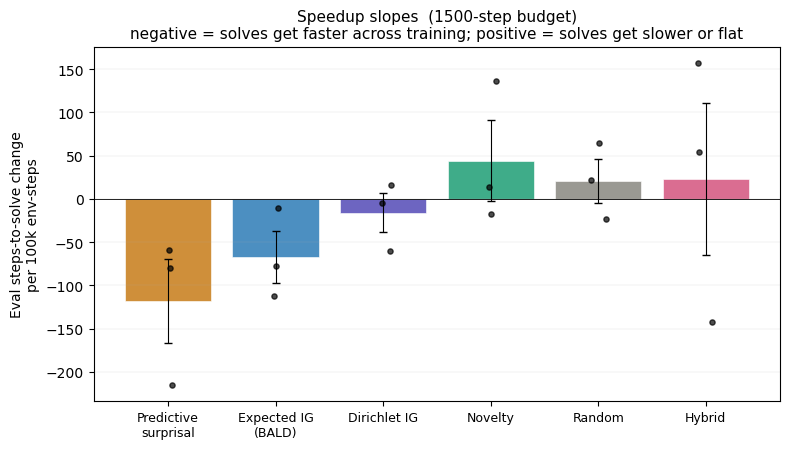

In [9]:
def speedup_slopes(runs_dir):
    out = {c: [] for c in CONDITION_ORDER}
    for d in sorted(Path(runs_dir).iterdir()):
        if not d.is_dir() or '_seed' not in d.name:
            continue
        cond, _ = d.name.rsplit('_seed', 1)
        if cond not in out:
            continue
        eh_path = d / 'eval_history.json'
        if not eh_path.exists():
            continue
        eh = json.load(open(eh_path))
        xs, ys = [], []
        for e in eh:
            v = e.get('eval_mean_steps_to_solve')
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            xs.append(e['global_step'])
            ys.append(v)
        if len(xs) >= 3:
            slope, _ = np.polyfit(xs, ys, 1)
            out[cond].append(slope * 100_000)
    return out

slopes_1500 = speedup_slopes(PROJECT / 'runs_white_1500')

fig, ax = plt.subplots(figsize=(8.0, 4.6))
np.random.seed(0)
for i, cond in enumerate(CONDITION_ORDER):
    vals = slopes_1500.get(cond, [])
    if not vals:
        continue
    arr = np.array(vals, dtype=float)
    m = float(arr.mean())
    s = float(arr.std(ddof=1) / np.sqrt(len(arr))) if len(arr) > 1 else 0.0
    ax.bar(i, m, yerr=s, color=CONDITION_COLORS[cond], alpha=0.85,
           edgecolor='white', linewidth=0.5,
           error_kw={'linewidth': 0.8, 'capsize': 3})
    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color='black', s=14, alpha=0.7, zorder=3)
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(range(len(CONDITION_ORDER)))
ax.set_xticklabels([CONDITION_LABELS_BAR[c] for c in CONDITION_ORDER], fontsize=9)
ax.set_ylabel('Eval steps-to-solve change\nper 100k env-steps')
ax.set_title('Speedup slopes  (1500-step budget)\n'
             'negative = solves get faster across training; positive = solves get slower or flat',
             fontsize=11)
ax.grid(True, axis='y', linewidth=0.3, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / '6_speedup_slopes_1500.png', dpi=220)
fig.savefig(OUT_DIR / '6_speedup_slopes_1500.pdf')
plt.show()

## Plot 7: tile-visit heatmaps (600 + 1500 budgets, final policy)

Loads each `agent.pt`, rolls out 10 evaluation episodes per seed (30 per condition), accumulates tile-visit counts, normalizes to share-of-visits per tile.

Rolling out at 600-step budget...


Rolling out at 1500-step budget...


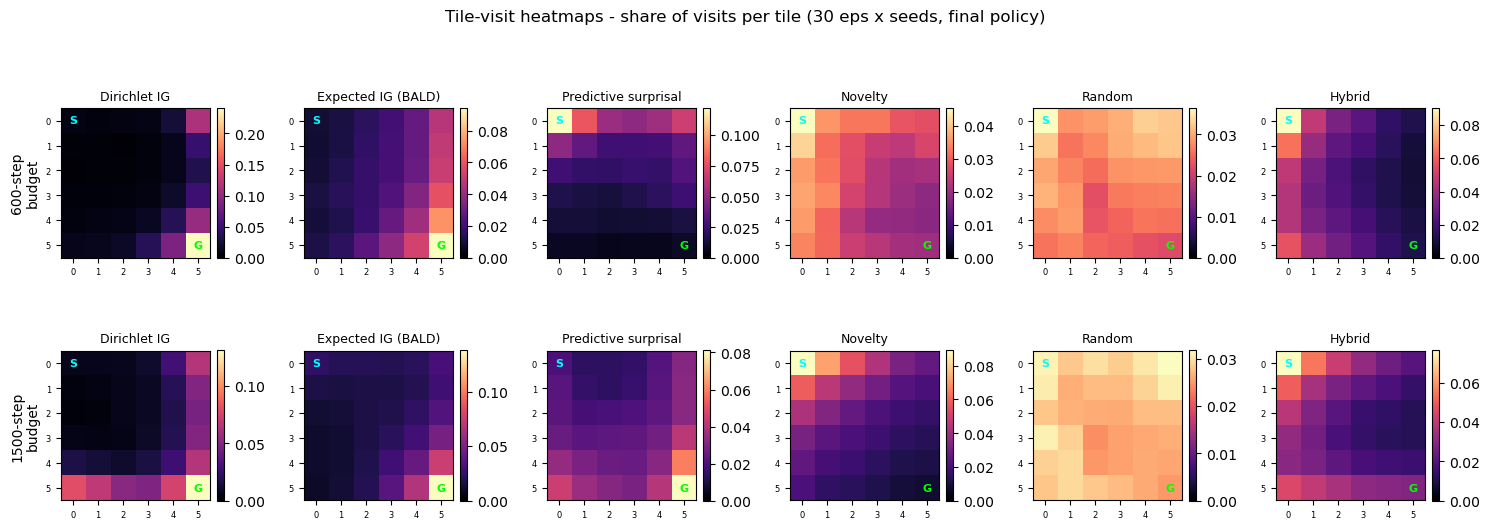

In [9]:
import sys
import torch
sys.path.insert(0, str(PROJECT))
from chromatic_white.env import ChromaticWhiteEnv, GRID_SIZE, NUM_ACTIONS
from chromatic_white.agent import ActorCriticGRU, ActorCriticConfig

HEATMAP_ORDER = ['info_gain', 'expected_info_gain', 'surprisal', 'novelty', 'random', 'hybrid']

def collect_visits(runs_dir, max_episode_steps, n_eps_per_seed=10, n_seeds=3):
    out = {}
    env_kwargs = {'max_steps': max_episode_steps, 'n_base_color_tiles_frac': 0.25}
    for cond in HEATMAP_ORDER:
        counts = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float64)
        for seed_idx in range(n_seeds):
            run_dir = Path(runs_dir) / f'{cond}_seed{seed_idx}'
            if not run_dir.exists():
                continue
            agent_path = run_dir / 'agent.pt'
            if cond == 'random' or not agent_path.exists():
                agent = None
            else:
                cfg = ActorCriticConfig(obs_dim=ChromaticWhiteEnv(**env_kwargs).OBS_DIM,
                                        num_actions=NUM_ACTIONS, hidden_dim=256, mlp_hidden=256)
                agent = ActorCriticGRU(cfg)
                agent.load_state_dict(torch.load(agent_path, map_location='cpu'))
                agent.eval()
            for ep in range(n_eps_per_seed):
                base = 900_000 + seed_idx * 100 + ep
                env = ChromaticWhiteEnv(**env_kwargs, seed=base)
                obs = env.reset()
                rng = np.random.default_rng(base)
                if agent is not None:
                    h = agent.initial_hidden(1, torch.device('cpu'))
                while not env.done:
                    counts[env.py, env.px] += 1
                    if agent is None:
                        a = int(rng.integers(NUM_ACTIONS))
                    else:
                        with torch.no_grad():
                            obs_t = torch.from_numpy(obs).float().unsqueeze(0)
                            action, _, _, _, _, h = agent.get_action(obs_t, h)
                            a = int(action.item())
                    obs, _, _, _ = env.step(a)
                counts[env.py, env.px] += 1
        if counts.sum() > 0:
            counts /= counts.sum()
        out[cond] = counts
    return out

print('Rolling out at 600-step budget...')
visits_600 = collect_visits(PROJECT / 'runs_white_600', 600)
print('Rolling out at 1500-step budget...')
visits_1500 = collect_visits(PROJECT / 'runs_white_1500', 1500)

fig, axes = plt.subplots(2, len(HEATMAP_ORDER),
                         figsize=(2.5 * len(HEATMAP_ORDER), 5.6), squeeze=False)
for ax_row, vmap, label in [(axes[0], visits_600, '600-step\nbudget'),
                              (axes[1], visits_1500, '1500-step\nbudget')]:
    for ax, cond in zip(ax_row, HEATMAP_ORDER):
        v = vmap.get(cond)
        if v is None or v.sum() == 0:
            ax.set_axis_off()
            ax.set_title(CONDITION_LABELS_LINE[cond], fontsize=9)
            continue
        im = ax.imshow(v, cmap='magma', aspect='equal', vmin=0)
        ax.set_title(CONDITION_LABELS_LINE[cond], fontsize=9)
        ax.set_xticks(range(GRID_SIZE))
        ax.set_yticks(range(GRID_SIZE))
        ax.tick_params(labelsize=6)
        ax.text(0, 0, 'S', color='cyan', ha='center', va='center',
                fontsize=8, fontweight='bold')
        ax.text(GRID_SIZE - 1, GRID_SIZE - 1, 'G', color='lime', ha='center', va='center',
                fontsize=8, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax_row[0].set_ylabel(label, fontsize=10)
fig.suptitle('Tile-visit heatmaps - share of visits per tile (30 eps x seeds, final policy)',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT_DIR / '7_trajectory_heatmaps.png', dpi=220)
fig.savefig(OUT_DIR / '7_trajectory_heatmaps.pdf')
plt.show()